In [1]:
import subprocess, os, shutil

REPO_URL = "https://github.com/safety-research/legibility.git"
REPO_DIR = "/workspace/18-4-2026"
EXP_DIR = os.path.join(REPO_DIR, "experiments", "2026", "15-4-2026")

# Clone or pull latest (fetch + reset to ensure we have the newest commit)
if not os.path.exists(os.path.join(REPO_DIR, ".git")):
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
else:
    subprocess.run(["git", "-C", REPO_DIR, "fetch", "origin"], check=True)
    subprocess.run(["git", "-C", REPO_DIR, "reset", "--hard", "origin/main"], check=True)


# Download results data from HuggingFace (too large for git)
from huggingface_hub import hf_hub_download
RESULTS_DIR = os.path.join(EXP_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)
for fname in ["classifications.json", "cot_texts.json"]:
    target = os.path.join(RESULTS_DIR, fname)
    if not os.path.exists(target):
        print(f"Downloading {fname} from HuggingFace...")
        hf_hub_download(
            repo_id="Noddybear/legibility-data",
            filename=f"results/{fname}",
            repo_type="dataset",
            local_dir=EXP_DIR,
        )
    else:
        print(f"CACHED: {fname}")

# Install dependencies
req_path = os.path.join(EXP_DIR, "requirements.txt")
if os.path.exists(req_path):
    subprocess.run(["pip", "install", "-q", "-r", req_path], check=True)
else:
    print(f"WARNING: {req_path} not found, skipping pip install")

# Set working directory so Path.cwd().parent resolves to experiment root
os.chdir(os.path.join(EXP_DIR, "notebooks"))

HEAD is now at c90b5e7 Fix Gemma 4 nested config: num_hidden_layers is under text_config


In [2]:
import sys
import json
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
from phase2_utils import PHASE2_RESULTS_DIR

ds_scores_path = PHASE2_RESULTS_DIR / "distributional_shift_scores.json"
r5_logprobs_path = PHASE2_RESULTS_DIR / "logprobs_R5.npz"

if ds_scores_path.exists():
    with open(ds_scores_path) as f:
        existing = json.load(f)
    r5_entries = [k for k in existing if k.endswith("|R5")]
    if r5_entries:
        print(f"CACHED: {len(r5_entries)} R5 entries already in distributional_shift_scores.json")
        print("Delete |R5 entries or logprobs_R5.npz to recompute.")
    else:
        print(f"Found {len(existing)} existing entries (no R5). Will add R5 entries.")
else:
    print("No distributional_shift_scores.json found -- will create with R5 entries.")

Found 448 existing entries (no R5). Will add R5 entries.


# NB10b: R5 Reader Perplexity (H200 GPU)

Compute R5 (Gemma-4-31B-IT) perplexity on all G1+G3 CoTs. This provides
the perplexity covariate needed for NB07b (reader R5 activation analysis).

Simpler than NB10 -- only needs one pass (R5 reader perplexity), not the
generator self-perplexity passes (already computed in NB10).

**Outputs:**
- `results/phase2/logprobs_R5.npz` -- raw per-token logprobs
- Updated `results/phase2/distributional_shift_scores.json` with `|R5` keyed entries

**GPU time:** ~1 hour

In [3]:
import sys
import json
import gc
import torch
import numpy as np
from pathlib import Path
from collections import Counter

sys.path.insert(0, str(Path.cwd().parent))
from phase2_utils import (
    join_cots_with_labels, load_model, compute_token_logprobs,
    compute_perplexity, print_phase1_summary, bootstrap_ci_metric,
    LOCAL_MODELS, PHASE2_RESULTS_DIR, RESULTS_DIR,
)

print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PHASE2_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CUDA available: True
GPU: NVIDIA H200
VRAM: 150.0 GB


In [4]:
print_phase1_summary()

# Get all classified CoTs with text for G1 and G3
all_cots_g1 = join_cots_with_labels(generator_ids=["G1"])
all_cots_g3 = join_cots_with_labels(generator_ids=["G3"])

# Sort for reproducible ordering (must match NB10)
all_cots_g1 = sorted(all_cots_g1, key=lambda x: (x['sample_id'], x['epoch']))
all_cots_g3 = sorted(all_cots_g3, key=lambda x: (x['sample_id'], x['epoch']))

# Combine G1 + G3 CoTs
all_cots_combined = list(all_cots_g1) + list(all_cots_g3)

print(f"G1 CoTs: {len(all_cots_g1)}")
print(f"G3 CoTs: {len(all_cots_g3)}")
print(f"Total CoTs for R5 scoring: {len(all_cots_combined)}")

# Load existing distributional shift scores (from NB10)
ds_scores_path = PHASE2_RESULTS_DIR / "distributional_shift_scores.json"
if ds_scores_path.exists():
    with open(ds_scores_path) as f:
        ds_scores = json.load(f)
    print(f"Loaded {len(ds_scores)} existing DS scores")
else:
    ds_scores = {}
    print("No existing DS scores -- will create new file")

# Load generator logprobs (from NB10) for KLD computation
g1_logprobs_path = PHASE2_RESULTS_DIR / "logprobs_G1.npz"
g3_logprobs_path = PHASE2_RESULTS_DIR / "logprobs_G3.npz"

gen_logprob_lookup = {}
if g1_logprobs_path.exists():
    g1_data = np.load(g1_logprobs_path, allow_pickle=True)
    g1_results = list(g1_data["results"])
    for i, c in enumerate(all_cots_g1):
        key = f"{c['sample_id']}|{c['generator_id']}|{c['epoch']}"
        gen_logprob_lookup[key] = g1_results[i]
    print(f"Loaded {len(g1_results)} G1 logprob records")
else:
    print("WARNING: logprobs_G1.npz not found -- run NB10 first for KLD computation")

if g3_logprobs_path.exists():
    g3_data = np.load(g3_logprobs_path, allow_pickle=True)
    g3_results = list(g3_data["results"])
    for i, c in enumerate(all_cots_g3):
        key = f"{c['sample_id']}|{c['generator_id']}|{c['epoch']}"
        gen_logprob_lookup[key] = g3_results[i]
    print(f"Loaded {len(g3_results)} G3 logprob records")
else:
    print("WARNING: logprobs_G3.npz not found -- run NB10 first for KLD computation")

Total records: 1285
Classified: 666, Filtered: 619
R4 transform: _t64
Label counts:
  ANSWER_LEAKED: 278
  FILTERED: 619
  ILLEGIBLE: 288
  REASONING_LEGIBLE: 100

Per-generator:
  G1: 219 classified (leaked=25%, legible=15%, illegible=60%)
  G2: 218 classified (leaked=69%, legible=17%, illegible=14%)
  G3: 229 classified (leaked=32%, legible=13%, illegible=55%)
  G1 within-Q pairs: 0
  G3 within-Q pairs: 0
G1 CoTs: 219
G3 CoTs: 229
Total CoTs for R5 scoring: 448
Loaded 448 existing DS scores
Loaded 219 G1 logprob records
Loaded 229 G3 logprob records


In [5]:
r5_logprobs_path = PHASE2_RESULTS_DIR / "logprobs_R5.npz"

if r5_logprobs_path.exists():
    print(f"CACHED: {r5_logprobs_path} exists, loading...")
    r5_logprob_data = np.load(r5_logprobs_path, allow_pickle=True)
    r5_results = list(r5_logprob_data["results"])
    print(f"  Loaded {len(r5_results)} R5 logprob records")
else:
    print("Loading R5 (Gemma-4-31B-IT) at full bf16...")
    model_r5, tok_r5 = load_model("R5")

    all_texts = [c['cot_text'] for c in all_cots_combined]
    print(f"Computing logprobs for {len(all_texts)} CoTs under R5...")
    r5_results = compute_token_logprobs(
        model_r5, tok_r5, all_texts,
        max_length=4096,
        batch_size=1,
    )

    # Save raw logprobs
    np.savez(
        r5_logprobs_path,
        results=np.array(r5_results, dtype=object),
        sample_keys=np.array([
            f"{c['sample_id']}|{c['generator_id']}|{c['epoch']}"
            for c in all_cots_combined
        ]),
    )
    print(f"  Saved to {r5_logprobs_path}")

    # Unload R5
    del model_r5, tok_r5
    gc.collect()
    torch.cuda.empty_cache()
    print(f"  GPU memory after unload: {torch.cuda.memory_allocated() / 1e9:.1f} GB")

# Report R5 perplexity stats
r5_ppls = [r['perplexity'] for r in r5_results]
print(f"\nR5 perplexity on all CoTs: mean={np.mean(r5_ppls):.2f}, "
      f"median={np.median(r5_ppls):.2f}, std={np.std(r5_ppls):.2f}")

# Break down by generator
n_g1 = len(all_cots_g1)
r5_ppls_g1 = r5_ppls[:n_g1]
r5_ppls_g3 = r5_ppls[n_g1:]
print(f"  R5 on G1 CoTs: mean={np.mean(r5_ppls_g1):.2f}, std={np.std(r5_ppls_g1):.2f}")
print(f"  R5 on G3 CoTs: mean={np.mean(r5_ppls_g3):.2f}, std={np.std(r5_ppls_g3):.2f}")

Loading R5 (Gemma-4-31B-IT) at full bf16...
Loading R5 (google/gemma-4-31b-it)...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/1188 [00:00<?, ?it/s]

  Loaded: 31.3B params, 4bit=False
Computing logprobs for 448 CoTs under R5...


Computing logprobs: 100%|██████████| 448/448 [00:45<00:00,  9.77it/s]


  Saved to /workspace/18-4-2026/experiments/2026/15-4-2026/results/phase2/logprobs_R5.npz
  GPU memory after unload: 0.0 GB

R5 perplexity on all CoTs: mean=36558.11, median=7.97, std=464909.37
  R5 on G1 CoTs: mean=22734.15, std=234777.46
  R5 on G3 CoTs: mean=49778.40, std=608088.82


In [6]:
# Compute KLD proxy for R5 and append to distributional shift scores
kld_proxies_r5 = []
n_added = 0

for i, c in enumerate(all_cots_combined):
    key = f"{c['sample_id']}|{c['generator_id']}|{c['epoch']}"
    reader_result = r5_results[i]
    gen_result = gen_logprob_lookup.get(key)

    if gen_result is None:
        continue

    # Reader mean surprisal (negative of mean logprob)
    reader_surprisal = -reader_result['mean_logprob']
    # Generator mean surprisal
    gen_surprisal = -gen_result['mean_logprob']
    # KLD proxy = reader_surprisal - generator_surprisal
    kld = reader_surprisal - gen_surprisal
    # Normalize by character count
    n_chars = max(len(c['cot_text']), 1)
    kld_per_char = kld / n_chars

    kld_proxies_r5.append(kld)

    # Key format: sample_id|generator_id|epoch|reader_id
    ds_key = f"{c['sample_id']}|{c['generator_id']}|{c['epoch']}|R5"
    ds_scores[ds_key] = {
        "reader_perplexity": float(reader_result['perplexity']),
        "reader_mean_logprob": float(reader_result['mean_logprob']),
        "reader_n_tokens": int(reader_result['n_tokens']),
        "generator_perplexity": float(gen_result['perplexity']),
        "generator_mean_logprob": float(gen_result['mean_logprob']),
        "generator_n_tokens": int(gen_result['n_tokens']),
        "kld_proxy": float(kld),
        "kld_proxy_per_char": float(kld_per_char),
    }
    n_added += 1

print(f"Added {n_added} R5 entries to distributional shift scores")
print(f"Total entries now: {len(ds_scores)}")
print(f"R5 KLD proxy: mean={np.mean(kld_proxies_r5):.3f}, "
      f"median={np.median(kld_proxies_r5):.3f}, std={np.std(kld_proxies_r5):.3f}")

# Save updated scores
with open(ds_scores_path, "w") as f:
    json.dump(ds_scores, f, indent=2)
print(f"Saved to {ds_scores_path}")

Added 448 R5 entries to distributional shift scores
Total entries now: 896
R5 KLD proxy: mean=1.908, median=1.645, std=1.169
Saved to /workspace/18-4-2026/experiments/2026/15-4-2026/results/phase2/distributional_shift_scores.json


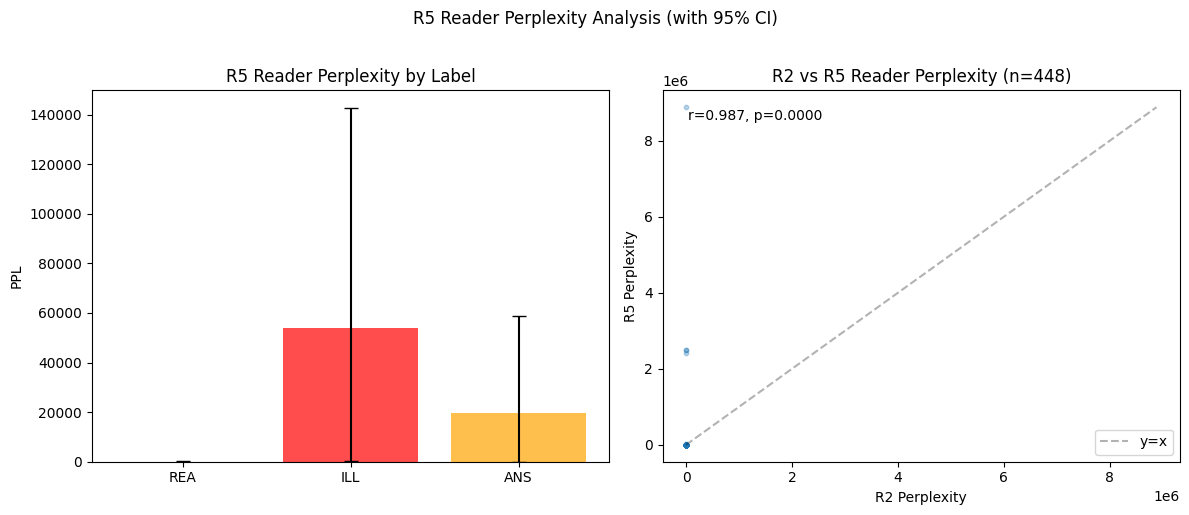


--- t-test: REASONING_LEGIBLE vs ILLEGIBLE (R5 perplexity) ---
  t=-1.453, p=0.1473, legible_mean=66.86, illegible_mean=53940.10


In [7]:
import matplotlib.pyplot as plt
from scipy import stats

# --- 1. R5 perplexity by legibility label ---
all_labels_combined = [c['label'] for c in all_cots_combined]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# R5 perplexity by label
ax = axes[0]
for label, color in [('REASONING_LEGIBLE', 'green'), ('ILLEGIBLE', 'red'), ('ANSWER_LEAKED', 'orange')]:
    mask = [l == label for l in all_labels_combined]
    subset = [p for p, m in zip(r5_ppls, mask) if m]
    if subset:
        mean_val, ci_lo, ci_hi = bootstrap_ci_metric(np.array(subset))
        ax.bar(label[:3], mean_val, yerr=[[mean_val - ci_lo], [ci_hi - mean_val]],
               color=color, alpha=0.7, capsize=5)
ax.set_title("R5 Reader Perplexity by Label")
ax.set_ylabel("PPL")

# R5 vs R2 perplexity comparison
ax = axes[1]
# Load R2 perplexities from existing DS scores
r2_ppls_by_key = {}
r5_ppls_by_key = {}
for key, val in ds_scores.items():
    if key.endswith("|R2"):
        base_key = key[:-3]  # strip |R2
        r2_ppls_by_key[base_key] = val['reader_perplexity']
    elif key.endswith("|R5"):
        base_key = key[:-3]  # strip |R5
        r5_ppls_by_key[base_key] = val['reader_perplexity']

# Find samples with both R2 and R5 scores
common_keys = set(r2_ppls_by_key.keys()) & set(r5_ppls_by_key.keys())
if common_keys:
    r2_vals = [r2_ppls_by_key[k] for k in sorted(common_keys)]
    r5_vals = [r5_ppls_by_key[k] for k in sorted(common_keys)]
    ax.scatter(r2_vals, r5_vals, alpha=0.3, s=10)
    ax.set_xlabel("R2 Perplexity")
    ax.set_ylabel("R5 Perplexity")
    ax.set_title(f"R2 vs R5 Reader Perplexity (n={len(common_keys)})")
    # Add correlation
    corr, p_val = stats.pearsonr(r2_vals, r5_vals)
    ax.text(0.05, 0.95, f"r={corr:.3f}, p={p_val:.4f}",
            transform=ax.transAxes, va='top', fontsize=10)
    # Add identity line
    max_val = max(max(r2_vals), max(r5_vals))
    ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='y=x')
    ax.legend()
else:
    ax.text(0.5, 0.5, "No R2 scores available for comparison",
            transform=ax.transAxes, ha='center')

fig.suptitle("R5 Reader Perplexity Analysis (with 95% CI)", y=1.02)
fig.tight_layout()
fig.savefig(PHASE2_RESULTS_DIR / "r5_ppl_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# t-test: legible vs illegible
print("\n--- t-test: REASONING_LEGIBLE vs ILLEGIBLE (R5 perplexity) ---")
leg_mask = [l == 'REASONING_LEGIBLE' for l in all_labels_combined]
ill_mask = [l == 'ILLEGIBLE' for l in all_labels_combined]
leg_ppls = [p for p, m in zip(r5_ppls, leg_mask) if m]
ill_ppls = [p for p, m in zip(r5_ppls, ill_mask) if m]
if len(leg_ppls) >= 5 and len(ill_ppls) >= 5:
    t_stat, p_val = stats.ttest_ind(leg_ppls, ill_ppls, equal_var=False)
    print(f"  t={t_stat:.3f}, p={p_val:.4f}, "
          f"legible_mean={np.mean(leg_ppls):.2f}, illegible_mean={np.mean(ill_ppls):.2f}")

In [8]:
print("NB10b complete.")
print(f"  R5 logprobs: {r5_logprobs_path}")
print(f"  DS scores: {ds_scores_path} ({len(ds_scores)} total entries)")
r5_count = sum(1 for k in ds_scores if k.endswith("|R5"))
r2_count = sum(1 for k in ds_scores if k.endswith("|R2"))
print(f"  R2 entries: {r2_count}, R5 entries: {r5_count}")

NB10b complete.
  R5 logprobs: /workspace/18-4-2026/experiments/2026/15-4-2026/results/phase2/logprobs_R5.npz
  DS scores: /workspace/18-4-2026/experiments/2026/15-4-2026/results/phase2/distributional_shift_scores.json (896 total entries)
  R2 entries: 448, R5 entries: 448
